# Evaluating confidence predictor

Here, we evaluate our three confidence prediction methods and assess how well they match to poorly predicted data points.

In [1]:
import re

import h5py
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as rt
import pandas as pd
import seaborn as sns
import torch
from Bio.SeqUtils import IUPACData
from scipy import stats

from tcr_antigen_prediction.models import TCRStructMap

In [ ]:
sess_options = rt.SessionOptions()
sess_options.intra_op_num_threads = 1
sess_options.inter_op_num_threads = 1

In [3]:
with h5py.File('data/processed/sequences.h5') as fh:
    cdr1_alphas = fh['cdr1_alpha'][:]
    cdr2_alphas = fh['cdr2_alpha'][:]
    cdr3_alphas = fh['cdr3_alpha'][:]
    cdr1_betas = fh['cdr1_beta'][:]
    cdr2_betas = fh['cdr2_beta'][:]
    cdr3_betas = fh['cdr3_beta'][:]
    peptides = fh['peptide'][:]
    mhcs = fh['mhc_pseudo'][:]

    folds = fh['fold'][:]
    labels = fh['label'][:]

results = pd.DataFrame(
    {
        'cdr1_alpha': list(cdr1_alphas),
        'cdr2_alpha': list(cdr2_alphas),
        'cdr3_alpha': list(cdr3_alphas),
        'cdr1_beta': list(cdr1_betas),
        'cdr2_beta': list(cdr2_betas),
        'cdr3_beta': list(cdr3_betas),
        'peptide': list(peptides),
        'mhc': list(mhcs),
        'fold': folds,
        'label': labels,
    }
)

In [4]:
indices = np.arange(len(labels))

In [5]:
with open('data/logs/train_confidence_predictor.log') as fh:
    training_log = fh.read()

In [6]:
match = re.search(r'INFO: Test indices: \[([\d+,\s]+)\]', training_log)
distance_regressor_test_indices = np.array([int(idx) for idx in re.findall(r'\d+', match.group(1))])

In [7]:
tcr_pmhcs = np.concatenate(
    [cdr1_alphas, cdr2_alphas, cdr3_alphas, cdr1_betas, cdr2_betas, cdr3_betas, peptides, mhcs], axis=1
)
tcr_pmhcs_flat = tcr_pmhcs.reshape(tcr_pmhcs.shape[0], -1)

In [8]:
fold_results = []
NUM_CONFIDENCE_PREDICTIONS = 5

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    fold_predictions = results.loc[distance_regressor_test_indices].copy()
    fold_predictions['holdout_fold'] = fold_num

    print('Loading model')
    model = TCRStructMap(drop_out_rate=0.6)
    model.load_state_dict(
        torch.load(
            f'models/TCRStructMap/model_{fold_num}.pt',
            map_location=torch.device('cpu'),
            weights_only=True,
        )
    )

    print('Making predictions')
    model.eval()

    predictions = model(
        torch.tensor(cdr1_alphas[distance_regressor_test_indices], dtype=torch.float32),
        torch.tensor(cdr2_alphas[distance_regressor_test_indices], dtype=torch.float32),
        torch.tensor(cdr3_alphas[distance_regressor_test_indices], dtype=torch.float32),
        torch.tensor(cdr1_betas[distance_regressor_test_indices], dtype=torch.float32),
        torch.tensor(cdr2_betas[distance_regressor_test_indices], dtype=torch.float32),
        torch.tensor(cdr3_betas[distance_regressor_test_indices], dtype=torch.float32),
        torch.tensor(peptides[distance_regressor_test_indices], dtype=torch.float32),
        torch.tensor(mhcs[distance_regressor_test_indices], dtype=torch.float32),
    )

    fold_predictions['prediction'] = predictions.squeeze(-1).detach().cpu().numpy()

    print('Making confidence prediction')
    model.train()
    for i in range(NUM_CONFIDENCE_PREDICTIONS):
        print(i + 1, 'of', NUM_CONFIDENCE_PREDICTIONS)
        confidence_prediction = model(
            torch.tensor(cdr1_alphas[distance_regressor_test_indices], dtype=torch.float32),
            torch.tensor(cdr2_alphas[distance_regressor_test_indices], dtype=torch.float32),
            torch.tensor(cdr3_alphas[distance_regressor_test_indices], dtype=torch.float32),
            torch.tensor(cdr1_betas[distance_regressor_test_indices], dtype=torch.float32),
            torch.tensor(cdr2_betas[distance_regressor_test_indices], dtype=torch.float32),
            torch.tensor(cdr3_betas[distance_regressor_test_indices], dtype=torch.float32),
            torch.tensor(peptides[distance_regressor_test_indices], dtype=torch.float32),
            torch.tensor(mhcs[distance_regressor_test_indices], dtype=torch.float32),
        )

        fold_predictions[f'confidence_prediction_{i}'] = confidence_prediction.squeeze(-1).detach().cpu().numpy()

    print('Making confidence prediction from regressor')
    sess = rt.InferenceSession(f'models/ConfidencePredictor/model_{fold_num}.onnx', sess_options=sess_options)
    input_name = sess.get_inputs()[0].name
    label_name = sess.get_outputs()[0].name
    confidence, *_ = sess.run(None, {'X': tcr_pmhcs_flat[distance_regressor_test_indices].astype(np.float32)})
    fold_predictions['confidence_distance_regressor'] = confidence.squeeze(-1)

    fold_results.append(fold_predictions)

    print('Finished fold')

results = pd.concat(fold_results).reset_index(drop=True)

Fold: 1
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor
Finished fold
Fold: 2
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor
Finished fold
Fold: 3
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor
Finished fold
Fold: 4
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor
Finished fold
Fold: 5
Loading model
Making predictions
Making confidence prediction
1 of 5
2 of 5
3 of 5
4 of 5
5 of 5
Making confidence prediction from regressor
Finished fold


In [ ]:
THRESHOLD = 0.5
results['prediction_binary'] = (results['prediction'] > THRESHOLD).apply(int)

In [10]:
results['residual_abs'] = np.abs(results['label'] - results['prediction'])
results['residual_squared'] = (results['label'] - results['prediction']) ** 2

In [11]:
results['correct'] = results['prediction_binary'] == results['label']

In [12]:
results['in_training_data'] = results['fold'] != results['holdout_fold']

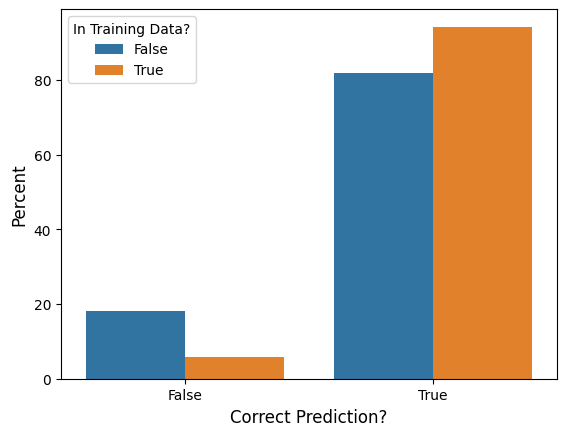

In [13]:
ax = sns.barplot(
    results.groupby('in_training_data')['correct']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percent')
    .reset_index(),
    x='correct',
    y='Percent',
    hue='in_training_data',
)

ax.legend_.set_title('In Training Data?')
plt.xlabel('Correct Prediction?', fontsize=12)
plt.ylabel('Percent', fontsize=12)

plt.show()

In [ ]:
amino_acid_olcs = np.array(sorted(IUPACData.protein_letters_3to1.values()))
amino_acid_olcs

array(['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P',
       'Q', 'R', 'S', 'T', 'V', 'W', 'Y'], dtype='<U1')

In [ ]:
with open('data/interim/peptides.txt') as fh:
    peptide_key = np.array(fh.read().rstrip().split('\n'))

peptide_distances = np.loadtxt('data/interim/peptide_distances.txt', dtype=int)

In [16]:
peptides_aa = np.array(
    [
        ''.join([amino_acid_olcs[one_hot.astype(bool)][0] for one_hot in peptide if np.sum(one_hot) > 0])
        for peptide in peptides
    ]
)

In [17]:
results['peptide_sequence'] = results['peptide'].map(
    lambda peptide: ''.join([amino_acid_olcs[one_hot.astype(bool)][0] for one_hot in peptide if np.sum(one_hot) > 0])
)

In [18]:
# TODO think about how to handle peptides that have been cropped...


def get_minimum_peptide_distance(peptide_sequence: str, fold: int) -> int:
    if peptide_sequence not in peptide_key:
        return np.nan

    training_peptides = peptides_aa[folds != fold]
    training_key_idxs = np.where(np.isin(peptide_key, training_peptides))[0]
    peptide_index = np.where(peptide_sequence == peptide_key)[0][0]

    return np.min(peptide_distances[peptide_index][training_key_idxs])

In [19]:
peptide_folds = results[['peptide_sequence', 'fold']].drop_duplicates()
peptide_folds['min_peptide_distance'] = peptide_folds.apply(
    lambda row: get_minimum_peptide_distance(row.peptide_sequence, row.fold),
    axis=1,
)

In [ ]:
results = results.merge(peptide_folds, how='left', on=['peptide_sequence', 'fold'])

## Confidence from Logits

In [ ]:
results['confidence_logits'] = np.max(np.stack([1 - results['prediction'], results['prediction']], axis=1), axis=1)

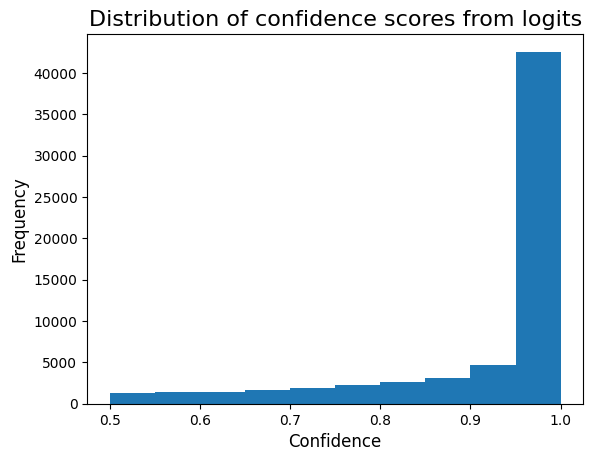

In [22]:
results['confidence_logits'].plot.hist()

plt.title('Distribution of confidence scores from logits', fontsize=16)
plt.xlabel('Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

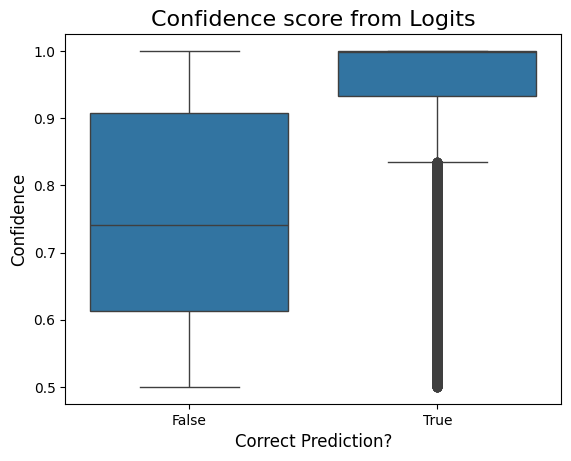

In [23]:
sns.boxplot(results, y='confidence_logits', x='correct')

plt.title('Confidence score from Logits', fontsize=16)
plt.xlabel('Correct Prediction?', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

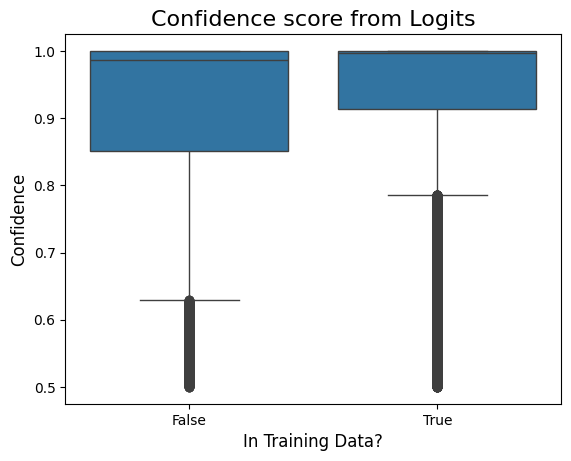

In [24]:
sns.boxplot(results, y='confidence_logits', x='in_training_data')

plt.title('Confidence score from Logits', fontsize=16)
plt.xlabel('In Training Data?', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

In [ ]:
results['confidence_logits_scaled'] = 2 * results['confidence_logits'] - 1

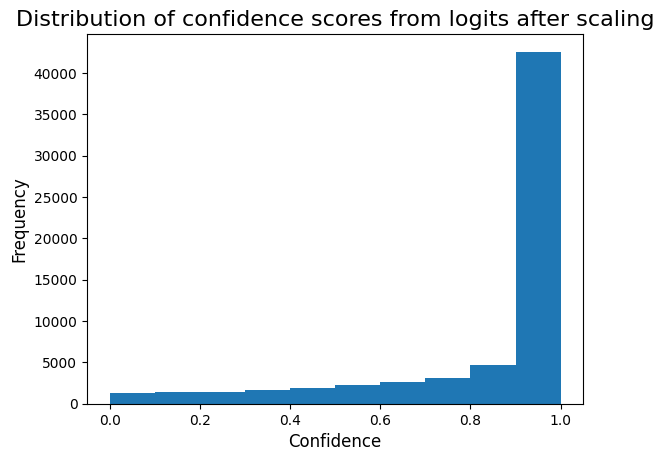

In [26]:
results['confidence_logits_scaled'].plot.hist()

plt.title('Distribution of confidence scores from logits after scaling', fontsize=16)
plt.xlabel('Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

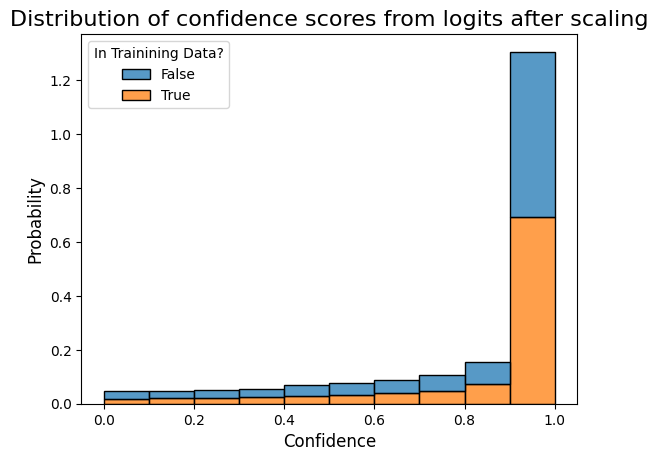

In [27]:
ax = sns.histplot(
    results,
    x='confidence_logits_scaled',
    hue='in_training_data',
    stat='probability',
    common_norm=False,
    multiple='stack',
    binwidth=0.1,
)

plt.title('Distribution of confidence scores from logits after scaling', fontsize=16)
plt.xlabel('Confidence', fontsize=12)
plt.ylabel('Probability', fontsize=12)
ax.legend_.set_title('In Trainining Data?')

plt.show()

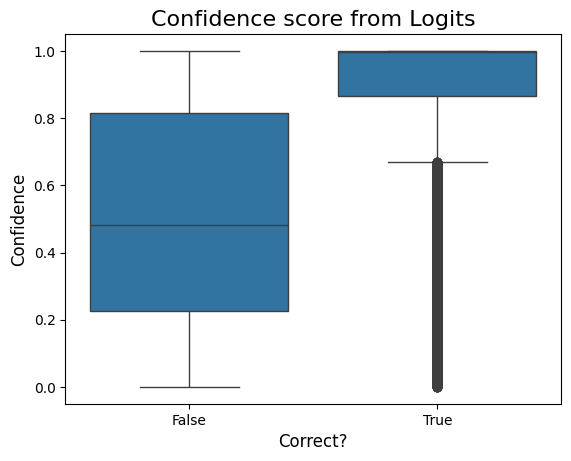

In [28]:
sns.boxplot(results, y='confidence_logits_scaled', x='correct')

plt.title('Confidence score from Logits', fontsize=16)
plt.xlabel('Correct?', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

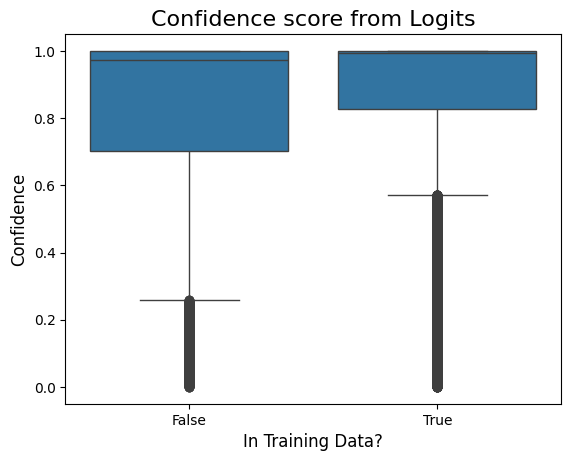

In [29]:
sns.boxplot(results, y='confidence_logits_scaled', x='in_training_data')

plt.title('Confidence score from Logits', fontsize=16)
plt.xlabel('In Training Data?', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

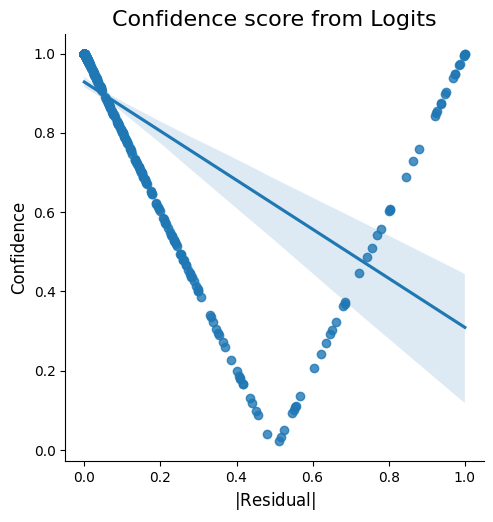

In [30]:
sns.lmplot(results.sample(500, random_state=123), x='residual_abs', y='confidence_logits_scaled')

plt.title('Confidence score from Logits', fontsize=16)
plt.xlabel(r'$|\text{Residual}|$', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

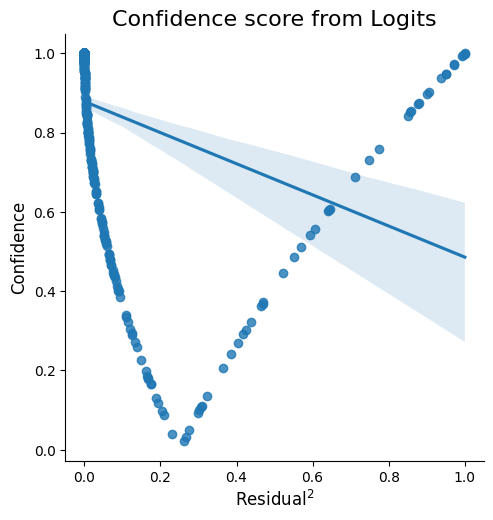

In [31]:
sns.lmplot(results.sample(500, random_state=123), x='residual_squared', y='confidence_logits_scaled')

plt.title('Confidence score from Logits', fontsize=16)
plt.xlabel(r'$\text{Residual}^2$', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

## Confidence from Monte-Carlo dropout

In [32]:
prediction_std = results.filter(regex=r'confidence_prediction_\d').apply(np.std, axis=1)

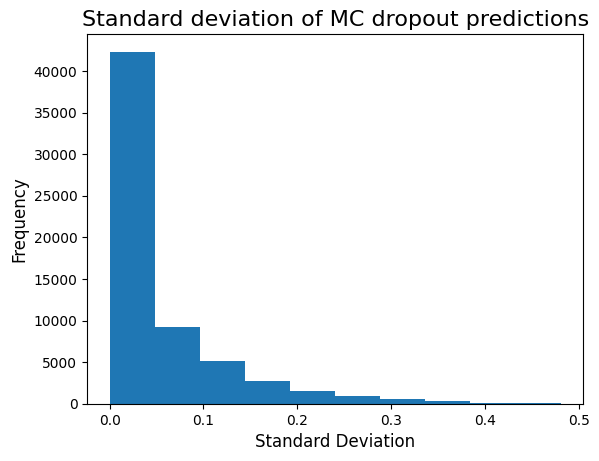

In [33]:
prediction_std.plot.hist()

plt.title('Standard deviation of MC dropout predictions', fontsize=16)
plt.xlabel('Standard Deviation', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

In [ ]:
confidence_prediction = 1 - prediction_std / prediction_std.max()

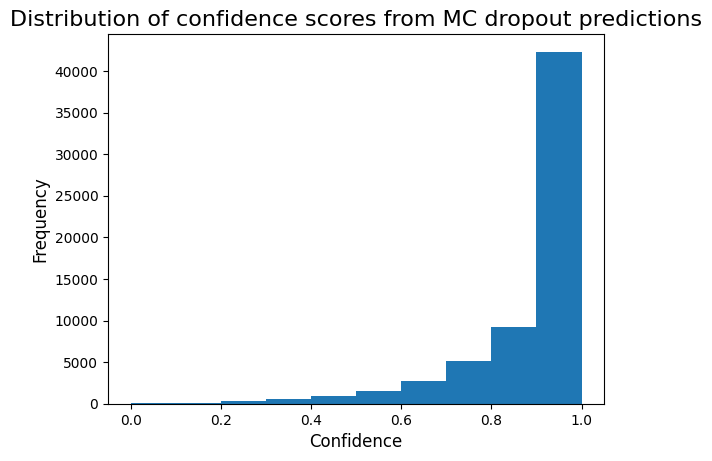

In [35]:
confidence_prediction.plot.hist()

plt.title('Distribution of confidence scores from MC dropout predictions', fontsize=16)
plt.xlabel('Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

In [36]:
results['confidence_mc_dropout'] = confidence_prediction

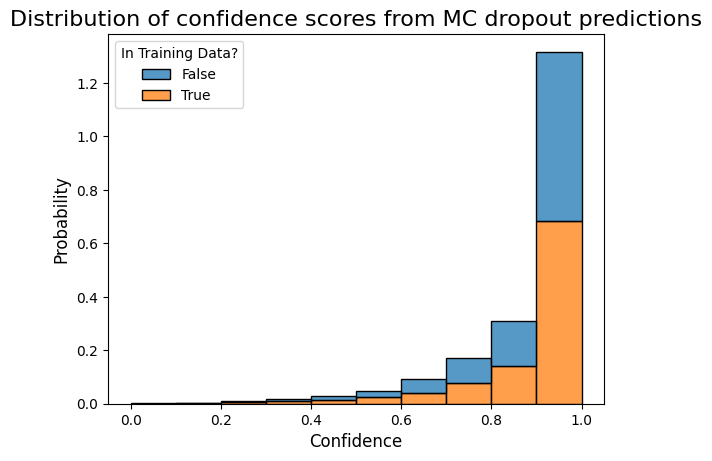

In [37]:
ax = sns.histplot(
    results,
    x='confidence_mc_dropout',
    hue='in_training_data',
    stat='probability',
    common_norm=False,
    multiple='stack',
    binwidth=0.1,
)

plt.title('Distribution of confidence scores from MC dropout predictions', fontsize=16)
plt.xlabel('Confidence', fontsize=12)
plt.ylabel('Probability', fontsize=12)
ax.legend_.set_title('In Training Data?')

plt.show()

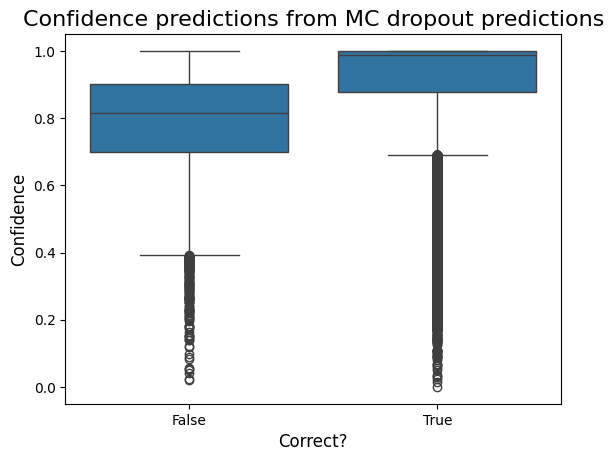

In [38]:
sns.boxplot(results, x='correct', y='confidence_mc_dropout')

plt.title('Confidence predictions from MC dropout predictions', fontsize=16)
plt.xlabel('Correct?', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

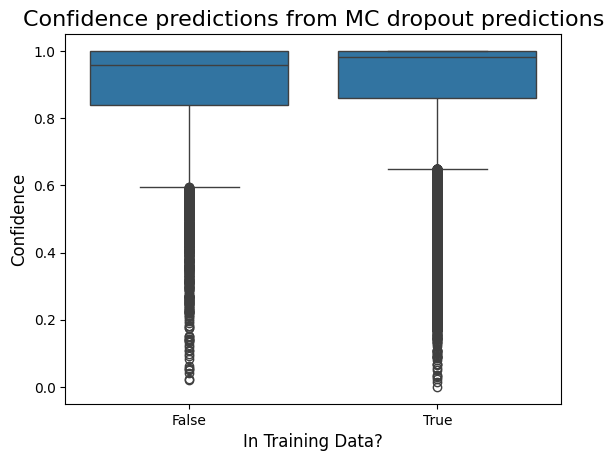

In [39]:
sns.boxplot(results, x='in_training_data', y='confidence_mc_dropout')

plt.title('Confidence predictions from MC dropout predictions', fontsize=16)
plt.xlabel('In Training Data?', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

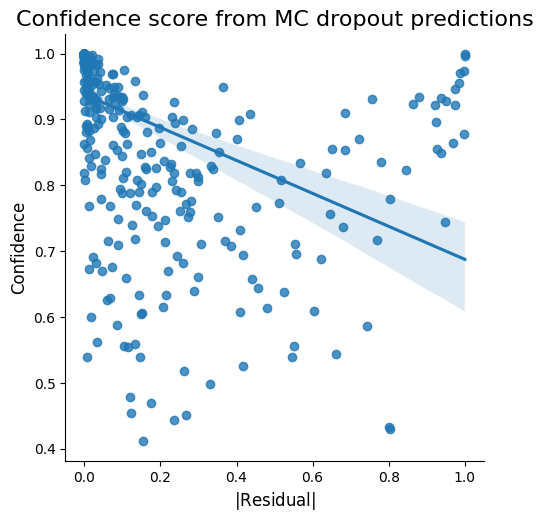

In [40]:
sns.lmplot(results.sample(500, random_state=123), x='residual_abs', y='confidence_mc_dropout')

plt.title('Confidence score from MC dropout predictions', fontsize=16)
plt.xlabel(r'$|\text{Residual}|$', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

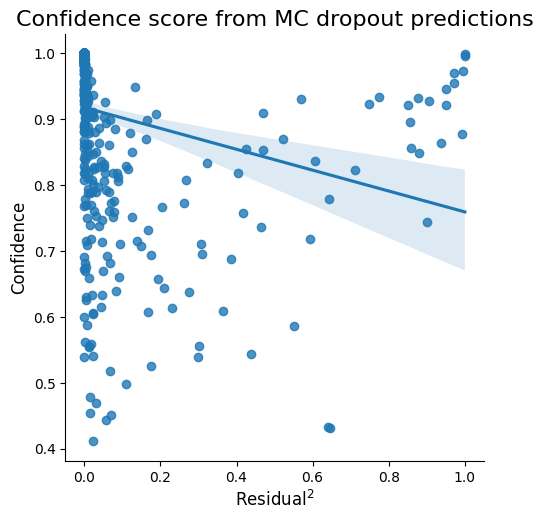

In [41]:
sns.lmplot(results.sample(500, random_state=123), x='residual_squared', y='confidence_mc_dropout')

plt.title('Confidence score from MC dropout predictions', fontsize=16)
plt.xlabel(r'$\text{Residual}^2$', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

## Distance Based Regressor

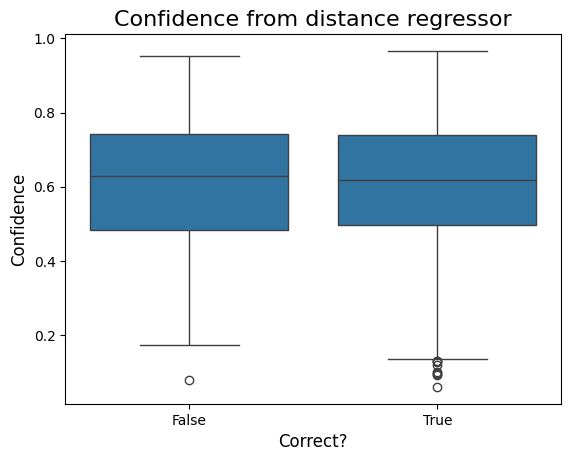

In [42]:
sns.boxplot(results, x='correct', y='confidence_distance_regressor')

plt.title('Confidence from distance regressor', fontsize=16)
plt.xlabel('Correct?', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

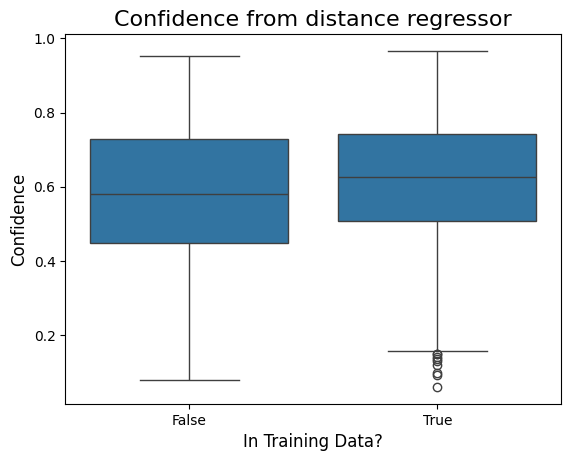

In [43]:
sns.boxplot(results, x='in_training_data', y='confidence_distance_regressor')

plt.title('Confidence from distance regressor', fontsize=16)
plt.xlabel('In Training Data?', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

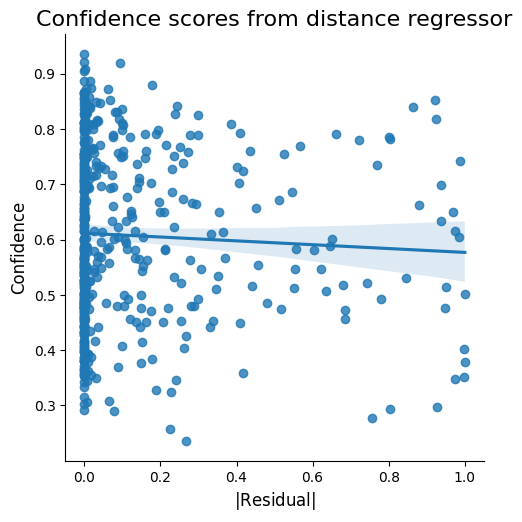

In [44]:
sns.lmplot(results.sample(500, random_state=123), x='residual_abs', y='confidence_distance_regressor')

plt.title('Confidence scores from distance regressor', fontsize=16)
plt.xlabel(r'$|\text{Residual}|$', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

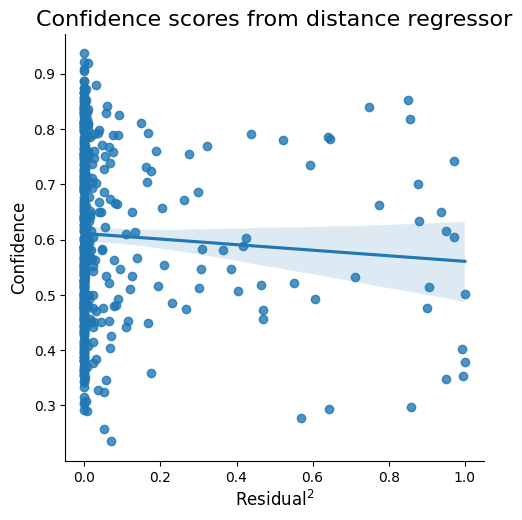

In [45]:
sns.lmplot(results.sample(500, random_state=123), x='residual_squared', y='confidence_distance_regressor')

plt.title('Confidence scores from distance regressor', fontsize=16)
plt.xlabel(r'$\text{Residual}^2$', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

plt.show()

## Comparison between approaches

### Correlation

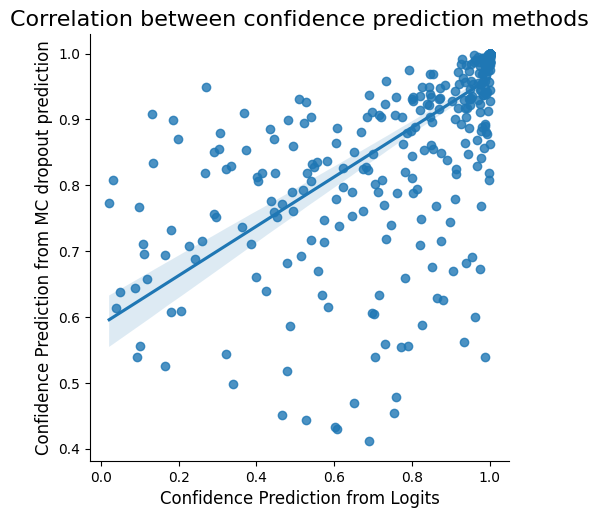

In [46]:
sns.lmplot(results.sample(500, random_state=123), x='confidence_logits_scaled', y='confidence_mc_dropout')

plt.title('Correlation between confidence prediction methods', fontsize=16)
plt.xlabel('Confidence Prediction from Logits', fontsize=12)
plt.ylabel('Confidence Prediction from MC dropout prediction', fontsize=12)

plt.show()

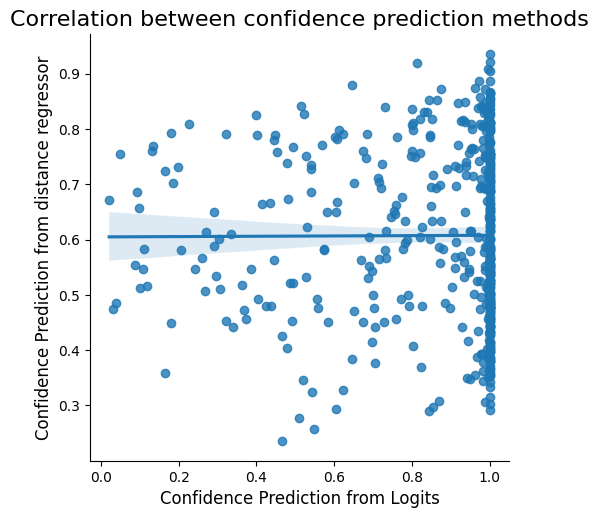

In [47]:
sns.lmplot(results.sample(500, random_state=123), x='confidence_logits_scaled', y='confidence_distance_regressor')

plt.title('Correlation between confidence prediction methods', fontsize=16)
plt.xlabel('Confidence Prediction from Logits', fontsize=12)
plt.ylabel('Confidence Prediction from distance regressor', fontsize=12)

plt.show()

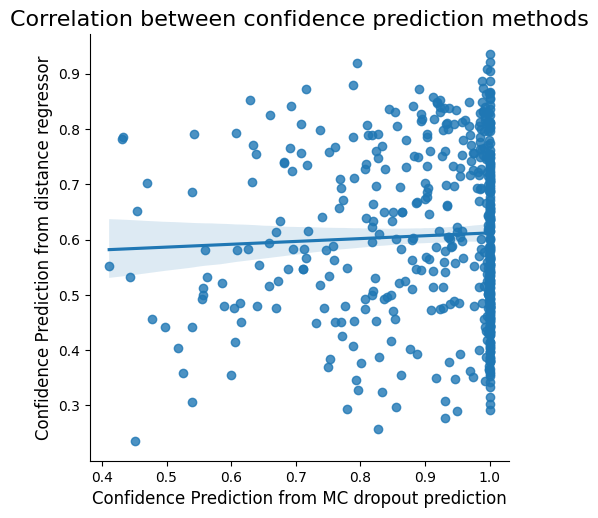

In [ ]:
sns.lmplot(results.sample(500, random_state=123), x='confidence_mc_dropout', y='confidence_distance_regressor')

plt.title('Correlation between confidence prediction methods', fontsize=16)
plt.xlabel('Confidence Prediction from MC dropout prediction', fontsize=12)
plt.ylabel('Confidence Prediction from distance regressor', fontsize=12)

plt.show()

### Comparison

In [ ]:
results_long = results.melt(
    id_vars=[
        'cdr1_alpha',
        'cdr2_alpha',
        'cdr3_alpha',
        'cdr1_beta',
        'cdr2_beta',
        'cdr3_beta',
        'peptide',
        'mhc',
        'fold',
        'label',
        'holdout_fold',
        'prediction',
        'prediction_binary',
        'in_training_data',
        'correct',
        'min_peptide_distance',
    ],
    value_vars=['confidence_logits', 'confidence_mc_dropout', 'confidence_distance_regressor'],
    var_name='method',
    value_name='confidence',
)

In [50]:
def transform_method_name(name: str) -> str:
    new_name = name.replace('_', ' from ', 1)
    new_name = new_name.replace('_', ' ')
    new_name = new_name.title()
    new_name = new_name.replace('Mc', 'MC')

    return new_name

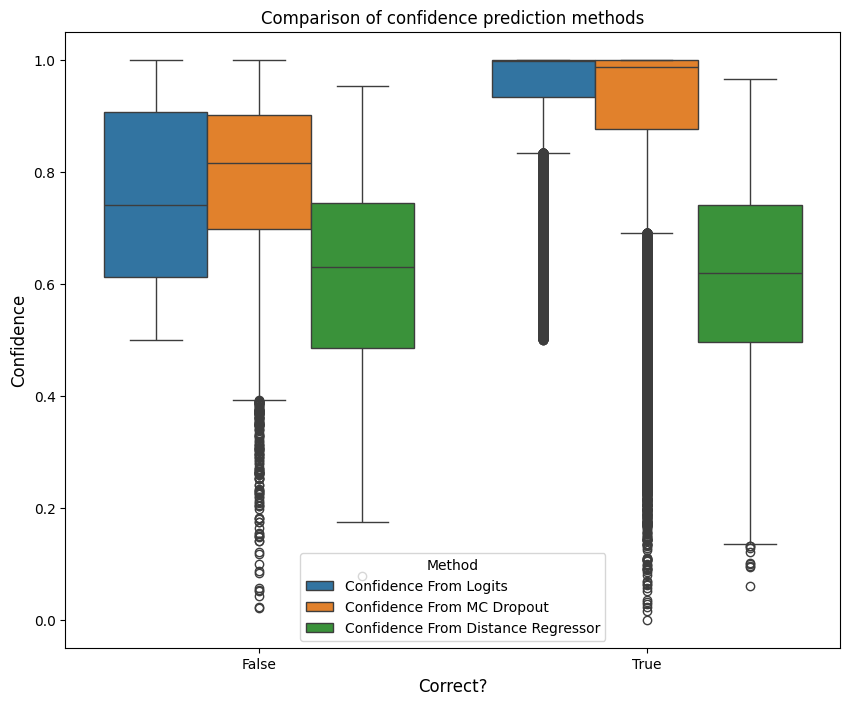

In [51]:
plt.figure(figsize=(10, 8))
ax = sns.boxplot(results_long, x='correct', y='confidence', hue='method')

plt.title('Comparison of confidence prediction methods')
plt.xlabel('Correct?', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
ax.legend_.set_title('Method')

for text in ax.legend_.get_texts():
    text.set_text(transform_method_name(text.get_text()))

plt.show()

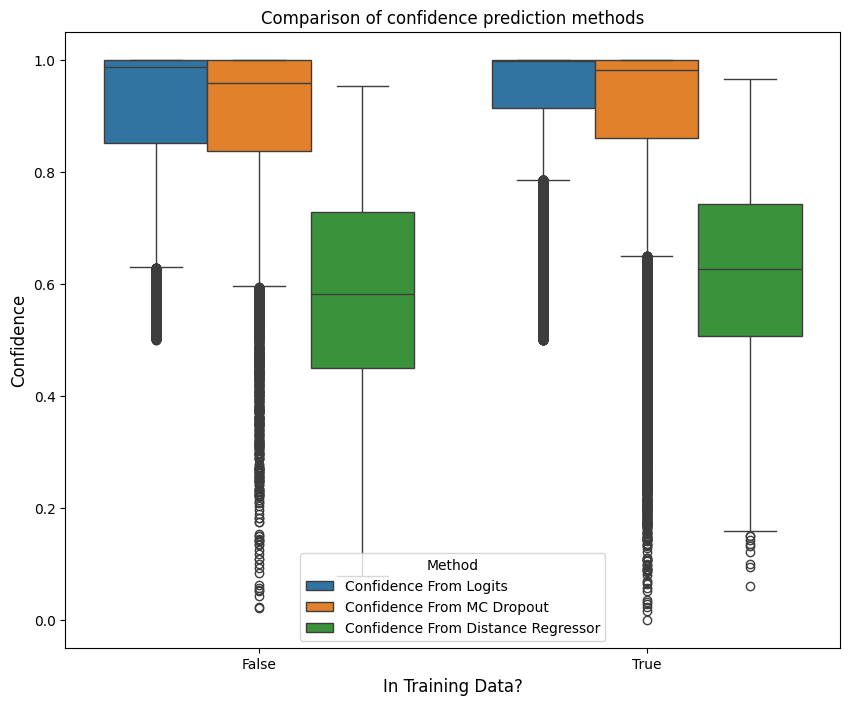

In [52]:
plt.figure(figsize=(10, 8))

ax = sns.boxplot(results_long, x='in_training_data', y='confidence', hue='method')

plt.title('Comparison of confidence prediction methods')
plt.xlabel('In Training Data?', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
ax.legend_.set_title('Method')

for text in ax.legend_.get_texts():
    text.set_text(transform_method_name(text.get_text()))

plt.show()

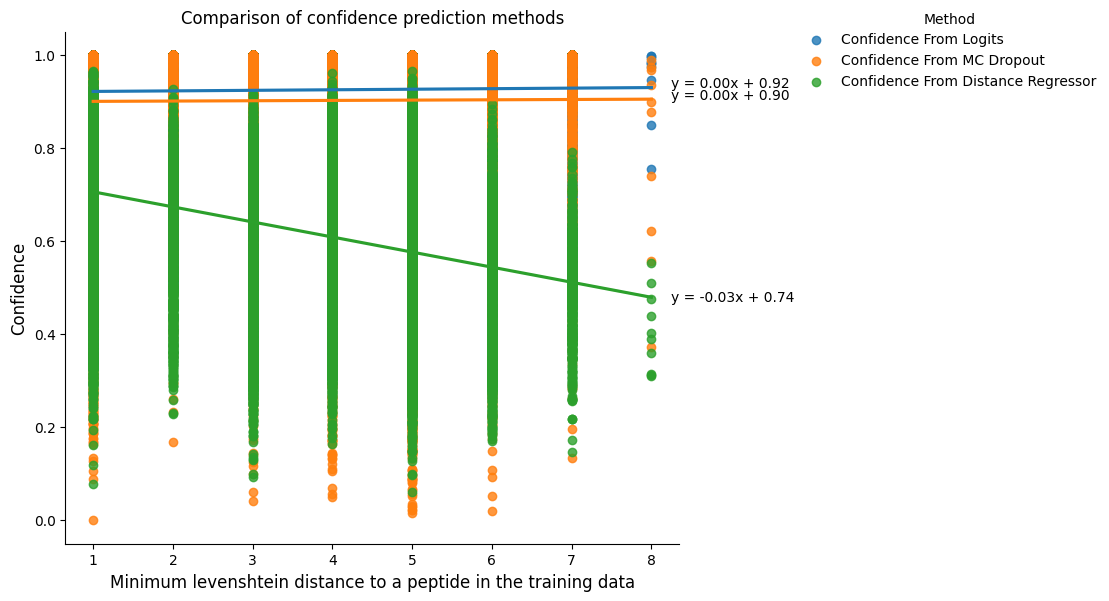

In [53]:
grid = sns.lmplot(results_long, x='min_peptide_distance', y='confidence', hue='method')

for method in results_long['method'].unique():
    subset = results_long[results_long['method'] == method].dropna()
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['confidence'])

    equation = f'y = {slope:.2f}x + {intercept:.2f}'
    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

plt.title('Comparison of confidence prediction methods')
plt.xlabel('Minimum levenshtein distance to a peptide in the training data', fontsize=12)
plt.ylabel('Confidence', fontsize=12)

grid.figure.set_size_inches(12, 6)

grid.legend.set_title('Method')
grid.legend.set_loc('upper right')

for text in grid.legend.get_texts():
    text.set_text(transform_method_name(text.get_text()))

plt.show()

In [54]:
lines = (
    results_long.dropna()
    .groupby(['method', 'fold'])
    .apply(
        lambda group: stats.linregress(group['min_peptide_distance'], group['confidence']),
        include_groups=False,
    )
)

lines.name = 'line'
lines = lines.reset_index()

lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = lines['line'].apply(pd.Series)

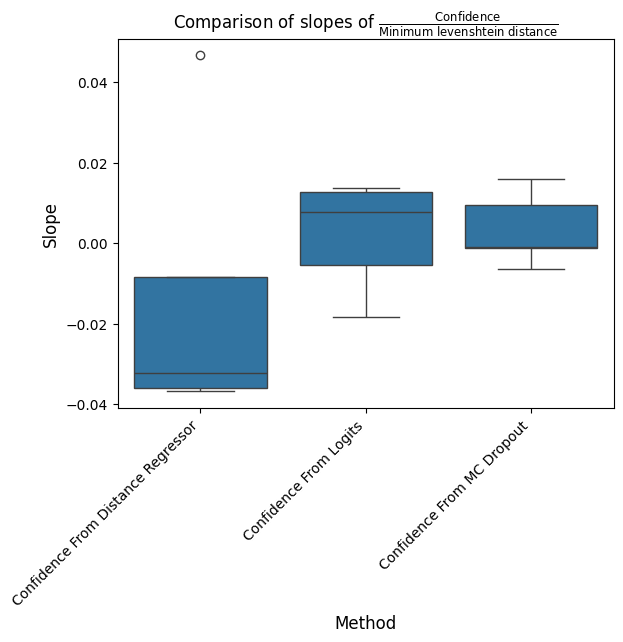

,mean,median,std
method,,,
Confidence From Distance Regressor,-0.013357,-0.032327,0.035496
Confidence From Logits,0.002069,0.007808,0.013708
Confidence From MC Dropout,0.003377,-0.000928,0.009065


In [55]:
sns.boxplot(x=lines['method'].apply(transform_method_name), y=lines['slope'])

plt.title(r'Comparison of slopes of $\frac{\text{Confidence}}{\text{Minimum levenshtein distance}}$')
plt.ylabel('Slope', fontsize=12)
plt.xlabel('Method', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

lines_agg = lines.groupby('method')['slope'].agg(['mean', 'median', 'std'])
lines_agg.index = lines_agg.index.map(transform_method_name)
lines_agg

In [ ]:
stats.kruskal(*[val for _, val in list(lines.groupby('method')['slope'])])

KruskalResult(statistic=2.960000000000008, pvalue=0.22763768838381188)